In [1]:
#Cell 1 — Upload file
from google.colab import files
uploaded = files.upload()


Saving insurance.csv to insurance.csv


In [39]:
#Cell 2 — Imports Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")

In [40]:
#Cell 3 — Upload Dataset
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [41]:
#Cell 4 — Inspection Of Dataset
print("Shape of dataset:", df.shape)
print(df.info())
print("Total Number of Missing Values\n",df.isnull().sum())
print(df.describe())

Shape of dataset: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
Total Number of Missing Values
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      

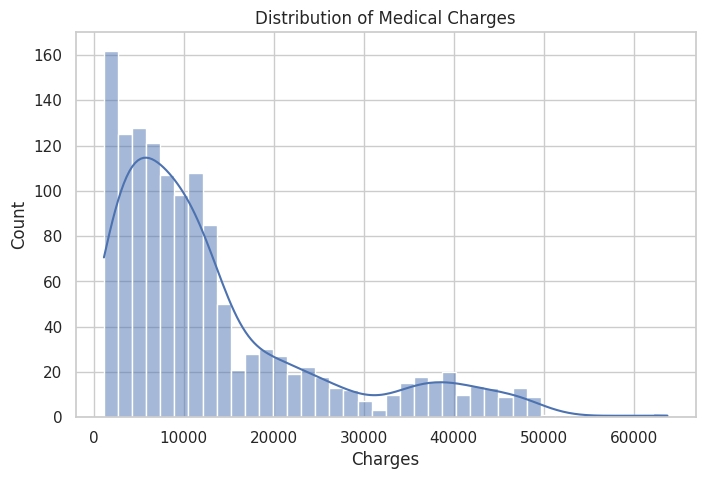

In [74]:
                                       ######Exploratory Data Analysis (EDA)####
#Cell 5 — Distribution of the target variable
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True, bins=40)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.savefig('charges_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

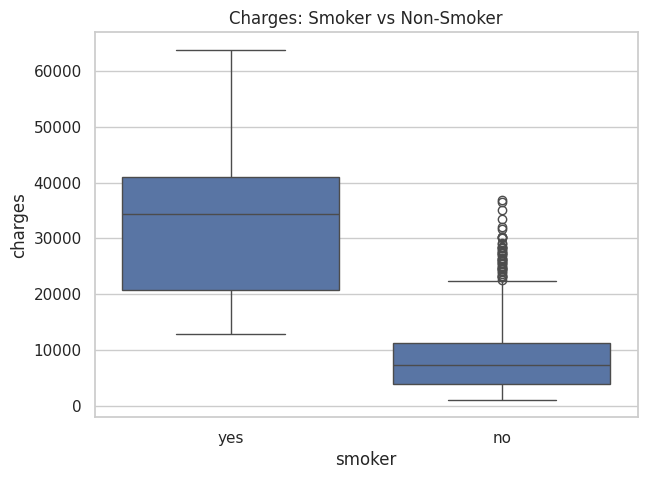

In [75]:
#Cell 6 — Does smoking affect charges?
plt.figure(figsize=(7,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges: Smoker vs Non-Smoker')
plt.savefig('Smoking_VS_Charges.png', dpi=150, bbox_inches='tight')
plt.show()

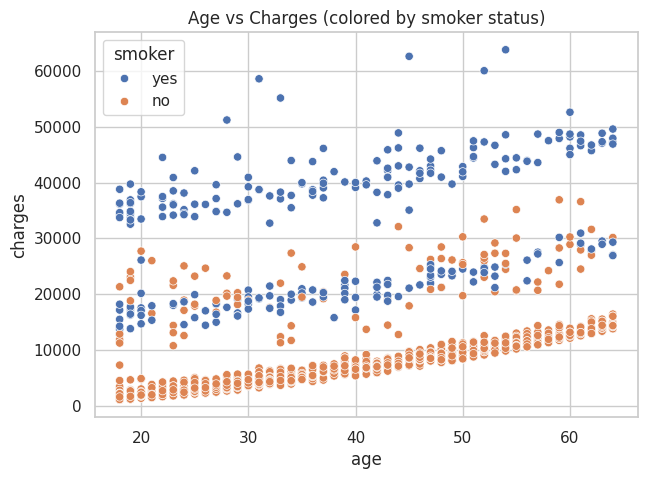

In [76]:
#Cell 7 — Does age affect charges?
plt.figure(figsize=(7,5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Age vs Charges (colored by smoker status)')
plt.savefig('age_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()

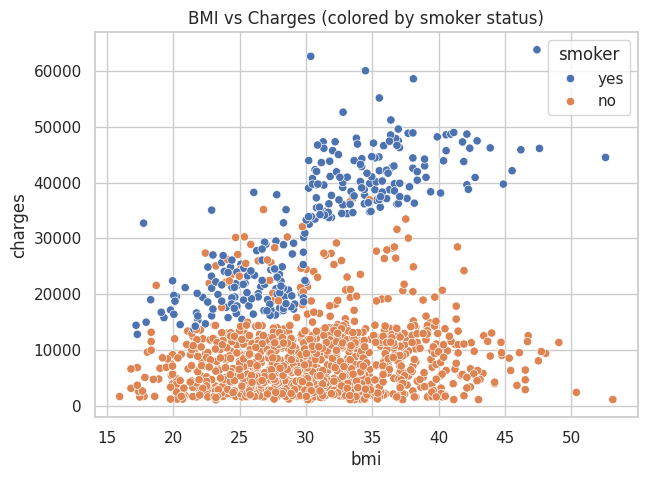

In [77]:
#Cell 8 — Does BMI affect charges?
plt.figure(figsize=(7,5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs Charges (colored by smoker status)')
plt.savefig('bmi_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()

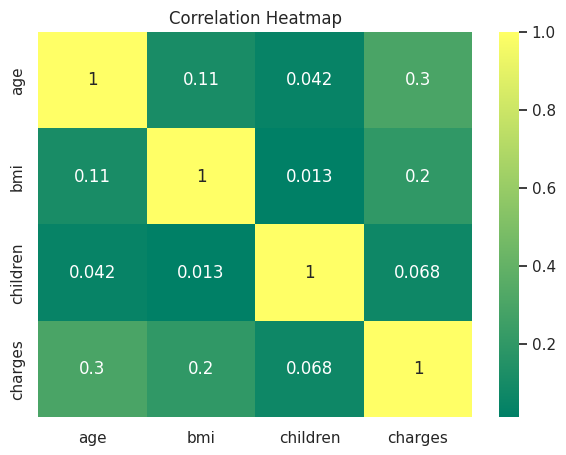

In [78]:
#Cell 9 — Correlation heatmap
plt.figure(figsize=(7,5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='summer')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

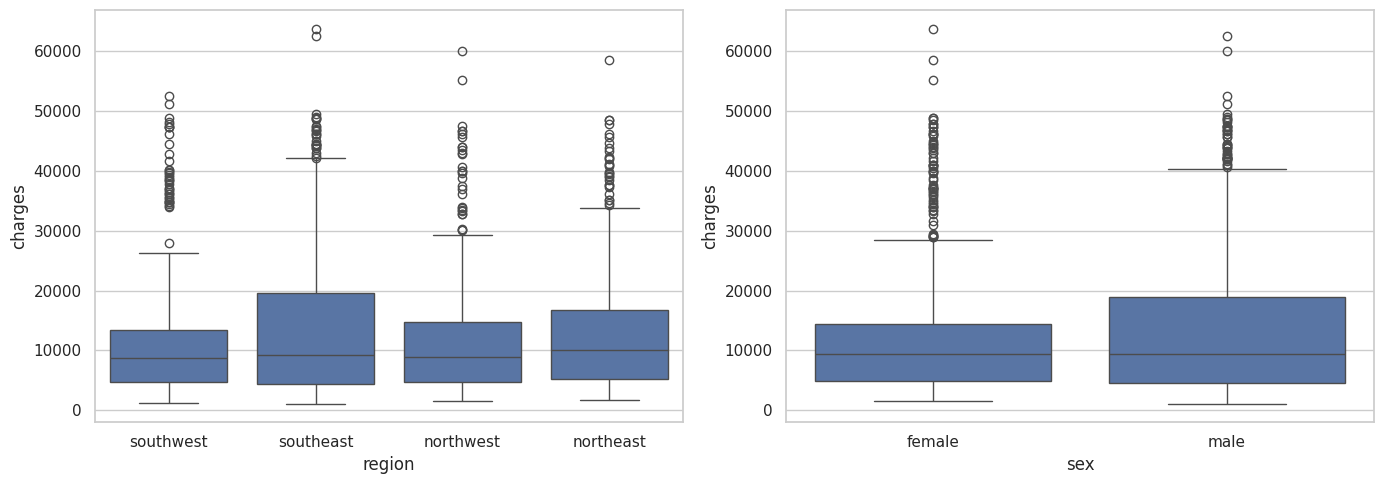

In [47]:
#Cell 10 — Region and sex effect
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(x='region', y='charges', data=df, ax=axes[0])
sns.boxplot(x='sex', y='charges', data=df, ax=axes[1])
plt.tight_layout()
plt.show()

In [48]:
         ###########Step 5: Feature Engineering (Encoding Categorical Variables)##############
#Cell 11 — Encode sex and smoker (binary categories → Label Encoding)
df_encoded = df.copy()

le = LabelEncoder()
df_encoded['sex'] = le.fit_transform(df_encoded['sex'])         # male=1, female=0 (or vice versa)
df_encoded['smoker'] = le.fit_transform(df_encoded['smoker'])   # yes=1, no=0
df_encoded.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [49]:
#Cell 12 — Encode region (this has 4 categories, so we use One-Hot Encoding instead of Label Encoding)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [50]:
#Cell 12b — Fix the dummy columns to be 0/1 instead of True/False
region_cols = ['region_northwest', 'region_southeast', 'region_southwest']
df_encoded[region_cols] = df_encoded[region_cols].astype(int)

df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [51]:
#Cell 13-Define Features (X) and Target (y)

X = df_encoded.drop('charges', axis=1)   # everything except the target
y = df_encoded['charges']                 # what we want to predict

print(X.columns)
print(X.shape, y.shape)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')
(1338, 8) (1338,)


In [52]:
#Cell 14-Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1070, 8)
Testing set size: (268, 8)


In [53]:
#Cell 15-Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Model trained successfully!
Intercept: -11931.219050326692
Coefficients: [ 2.56975706e+02 -1.85916916e+01  3.37092552e+02  4.25278784e+02
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]


In [54]:
              #########Evaluate the Model (Is it Weak or Strong?)###########
#Cell 16 — Make predictions on the test set
y_pred = model.predict(X_test)

In [55]:
#Cell 17 — Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("MAE (Mean Absolute Error):", mae)
print("RMSE (Root Mean Squared Error):", rmse)

R² Score: 0.7835929767120723
MAE (Mean Absolute Error): 4181.1944737536505
RMSE (Root Mean Squared Error): 5796.2846592762735


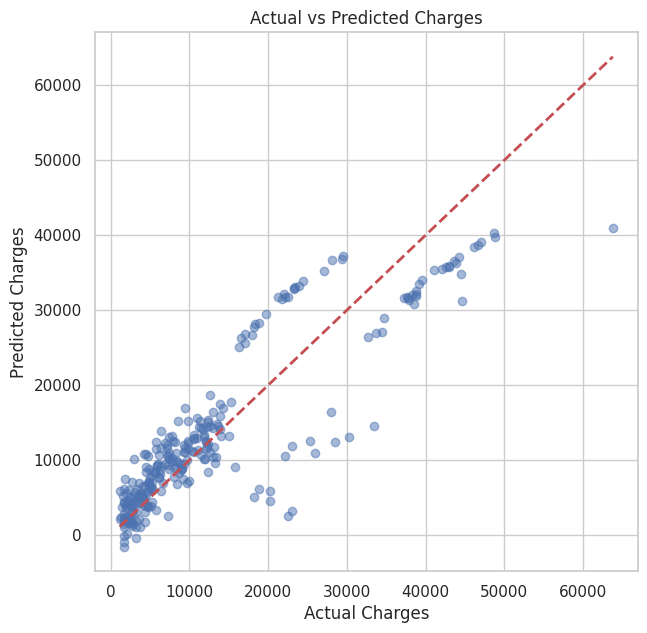

In [79]:
#Cell 18 — Visualize predictions vs actual
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')
plt.savefig('actual_vs_predicted_basics.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
          ######Strengthen the Model with Feature Engineering######
 ##Cell 19 — Create the interaction feature
df_encoded['bmi_smoker'] = df_encoded['bmi'] * df_encoded['smoker']
df_encoded[['bmi', 'smoker', 'bmi_smoker']].head()

,bmi,smoker,bmi_smoker
0,27.900,1,27.9
1,33.770,0,0.0
2,33.000,0,0.0
3,22.705,0,0.0
4,28.880,0,0.0


In [63]:
#Cell 20 — Also add a BMI risk flag (obese threshold, medically standard cutoff of 30)
df_encoded['is_obese'] = (df_encoded['bmi'] >= 30).astype(int)
df_encoded['obese_smoker'] = df_encoded['is_obese'] * df_encoded['smoker']

df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_smoker,is_obese,obese_smoker
0,19,0,27.900,0,1,16884.92400,0,0,1,27.9,0,0
1,18,1,33.770,1,0,1725.55230,0,1,0,0.0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0,0.0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0,0.0,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0,0.0,0,0


In [64]:
#Cell 21 — Rebuild X and y with the new features, and redo the split
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X.columns.tolist())
print(X_train.shape, X_test.shape)

['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker', 'is_obese', 'obese_smoker']
(1070, 11) (268, 11)


In [65]:
#Cell 22 — Retrain the model on the improved features
model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

r2_new = r2_score(y_test, y_pred2)
mae_new = mean_absolute_error(y_test, y_pred2)
rmse_new = np.sqrt(mean_squared_error(y_test, y_pred2))

print("New R² Score:", r2_new)
print("New MAE:", mae_new)
print("New RMSE:", rmse_new)

New R² Score: 0.8792130696965282
New MAE: 2378.2525314696936
New RMSE: 4330.359997783007


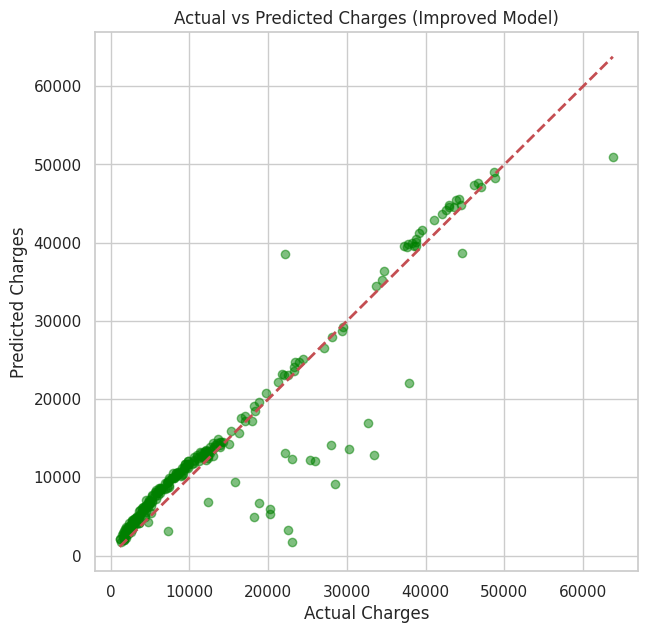

In [80]:
#Cell 23-Re-visualize to Confirm the Fix
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred2, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges (Improved Model)')
plt.savefig('actual_vs_predictedf_improved.png', dpi=150, bbox_inches='tight')
plt.show()

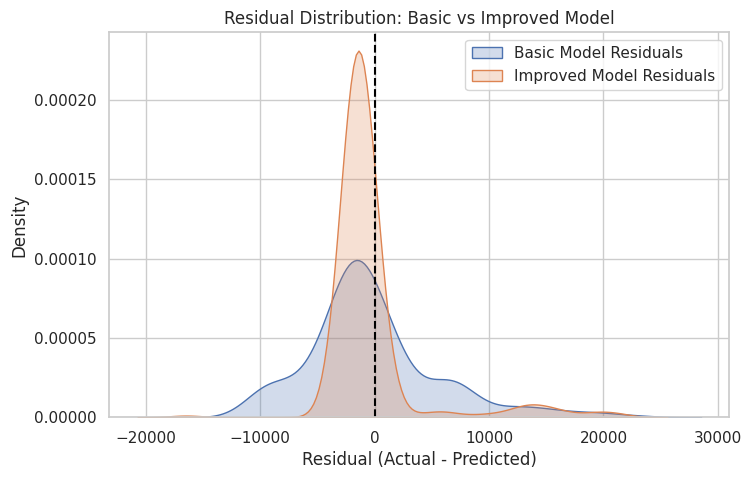

In [83]:
#Cell 24 — Also compare both models' residuals (errors) side by side
plt.figure(figsize=(8,5))
residuals_old = y_test - y_pred
residuals_new = y_test - y_pred2

sns.kdeplot(residuals_old, label='Basic Model Residuals', fill=True)
sns.kdeplot(residuals_new, label='Improved Model Residuals', fill=True)
plt.axvline(0, color='black', linestyle='--')
plt.title('Residual Distribution: Basic vs Improved Model')
plt.xlabel('Residual (Actual - Predicted)')
plt.legend()
plt.savefig('residual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
            #####Test the Model on Brand-New, Unseen Data#####
#Cell 25 — Create new synthetic test cases
new_data = pd.DataFrame({
    'age':        [25, 45, 60, 30, 52],
    'sex':        [1, 0, 1, 0, 1],       # 1=male, 0=female (check your LabelEncoder mapping)
    'bmi':        [22.5, 31.2, 28.7, 35.8, 40.1],
    'children':   [0, 2, 3, 1, 0],
    'smoker':     [0, 0, 1, 1, 1],       # 1=yes, 0=no
    'region_northwest': [1, 0, 0, 0, 0],
    'region_southeast': [0, 1, 0, 1, 1],
    'region_southwest': [0, 0, 1, 0, 0],
})

# Recreate the same engineered features we used for training
new_data['bmi_smoker'] = new_data['bmi'] * new_data['smoker']
new_data['is_obese'] = (new_data['bmi'] >= 30).astype(int)
new_data['obese_smoker'] = new_data['is_obese'] * new_data['smoker']


new_data = new_data[X_train.columns]

new_data

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,bmi_smoker,is_obese,obese_smoker
0,25,1,22.5,0,0,1,0,0,0.0,0,0
1,45,0,31.2,2,0,0,1,0,0.0,1,0
2,60,1,28.7,3,1,0,0,1,28.7,0,0
3,30,0,35.8,1,1,0,1,0,35.8,1,1
4,52,1,40.1,0,1,0,1,0,40.1,1,1


In [69]:
# Cell 26 — Predict on these new people
new_predictions = model2.predict(new_data)

for i, pred in enumerate(new_predictions):
    print(f"Person {i+1}: Predicted Charges = ${pred:,.2f}")

Person 1: Predicted Charges = $3,985.09
Person 2: Predicted Charges = $10,700.21
Person 3: Predicted Charges = $28,374.81
Person 4: Predicted Charges = $39,774.00
Person 5: Predicted Charges = $46,513.35


In [70]:
#Cell 27-Save the Trained Model (so it's reusable, not just in-notebook)
import joblib

joblib.dump(model2, 'insurance_model.pkl')
print("Model saved as insurance_model.pkl")

Model saved as insurance_model.pkl


In [71]:
from google.colab import files
files.download('insurance_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
#Cell 29-Feature Importance Summary (for your README)
importance_df = pd.DataFrame({'Feature': X_train.columns,'Coefficient': model2.coef_}).sort_values(by='Coefficient', key=abs, ascending=False)

print(importance_df)

             Feature   Coefficient
10      obese_smoker  15451.494628
4             smoker   1407.695325
7   region_southwest  -1381.544378
6   region_southeast   -768.179444
1                sex   -556.061626
3           children    470.633712
8         bmi_smoker    464.880123
5   region_northwest   -432.584757
9           is_obese    326.762382
0                age    262.798169
2                bmi     -3.371595
